In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics supervision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 29.0 MB/s eta 0:00:00


In [ ]:
!nvidia-smi

Tue Feb 24 11:14:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:


# Copy the dataset ZIP to the current working directory
!scp -r "/content/drive/MyDrive/Colab_Notebooks/vehicle-detection.zip" . # REPLACE THE SOURCE PATH WITH YOURS -> /content/drive/MyDrive/datasets/rock-paper-scissors-14.zip

In [ ]:
!unzip /content/vehicle-detection.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/labels/Screenshot-2025-04-07-215645_png.rf.41ea7ce664e052543505dc89c696e939.txt  
  inflating: train/labels/Screenshot-2025-04-07-215645_png.rf.cafdb8b739000d563e63a3f879b77afd.txt  
  inflating: train/labels/Screenshot-2025-04-07-215649_png.rf.81f7918ce7f35393d074d28432d213fc.txt  
  inflating: train/labels/Screenshot-2025-04-07-215649_png.rf.892742101908a1d569db1f50605192b0.txt  
  inflating: train/labels/Screenshot-2025-04-07-215649_png.rf.917687f765b532174bdd19a7f68e46d9.txt  
  inflating: train/labels/Screenshot-2025-04-07-215704_png.rf.6b7dba37287abf9e21c6b40047a4bdc1.txt  
  inflating: train/labels/Screenshot-2025-04-07-215704_png.rf.bbfc45ff62361c03436e6044a4c08e89.txt  
  inflating: train/labels/Screenshot-2025-04-07-215704_png.rf.e5a16065a1220994548a25ba0260f4a4.txt  
  inflating: train/labels/Screenshot-2025-04-07-215708_png.rf.1d40b721d2349ab46f4fed39b51e2042.txt  
  inflating: train/labels/Screenshot-202

In [ ]:
dataset_location = "/content/vehicle-detection"

In [ ]:
!ls {dataset_location}

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
!cat {dataset_location}/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names: ['bus', 'car', 'van']

roboflow:
  workspace: personal-project-kej16
  project: vehicle-detection-vznzd-dkl8g
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/personal-project-kej16/vehicle-detection-vznzd-dkl8g/dataset/1

In [ ]:
!wget https://github.com/sunsmarterjie/yolov12/releases/download/v1.0/yolov12n.pt

--2026-02-24 11:14:53--  https://github.com/sunsmarterjie/yolov12/releases/download/v1.0/yolov12n.pt
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/928546208/99db71db-0946-4c10-94a0-b54baf471037?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-02-24T12%3A04%3A12Z&rscd=attachment%3B+filename%3Dyolov12n.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-02-24T11%3A03%3A41Z&ske=2026-02-24T12%3A04%3A12Z&sks=b&skv=2018-11-09&sig=Z7WgPLLt%2BJuf6I7eWC9LSkU%2FDywrC%2FpN49osx1kd9wc%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3MTkzMTk5NCwibmJmIjoxNzcxOTMxNjk0LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9i

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov12n.pt')

In [ ]:
from ultralytics import YOLO
import os

# Jalur (path) langsung ke file data.yaml Anda
dataset_yaml = '/content/vehicle-detection/data.yaml'

# Jumlah tahap pelatihan (5 kali)
total_tahap = 5

for tahap in range(1, total_tahap + 1):
    print(f"\n{'='*50}")
    print(f"🚀 MEMULAI PELATIHAN TAHAP {tahap}")
    print(f"{'='*50}\n")

    # 1. Menentukan model yang akan dimuat (load)
    if tahap == 1:
        # Tahap 1: Gunakan model dasar (contoh: yolov12n.pt, yolov8n.pt, dll.)
        model_path = 'yolov12n.pt'
    else:
        # Tahap 2 hingga 5: Gunakan 'last.pt' dari folder tahap sebelumnya
        model_path = f'Pelatihan/Tahap_{tahap-1}/weights/last.pt'

        # Periksa apakah file model dari tahap sebelumnya ada sebelum melanjutkan
        if not os.path.exists(model_path):
            print(f"❌ Error: Model {model_path} tidak ditemukan. Pelatihan dihentikan.")
            break

    # 2. Muat (load) model ke dalam variabel
    model = YOLO(model_path)

    # 3. Jalankan pelatihan dengan parameter Anda
    results = model.train(
        data=dataset_yaml,          # Menggunakan jalur (path) yang Anda berikan
        epochs=20,                  # 20 epoch untuk setiap putaran
        batch=16,
        imgsz=640,
        project='Pelatihan',        # Semua hasil akan disimpan di dalam folder utama ini
        name=f'Tahap_{tahap}',      # Nama sub-folder untuk setiap putaran pelatihan
        exist_ok=True,
        patience=5,                 # Berhenti lebih awal (early stopping) jika tidak ada peningkatan akurasi selama 5 epoch
        save_period=5,              # Simpan cadangan model (checkpoint) setiap 5 epoch
        val=True,                   # Lakukan validasi data
        verbose=True,               # Tampilkan proses detail selama pelatihan berjalan
        flipud=0.5,                 # Augmentasi data: probabilitas membalik gambar secara vertikal
    )

print("\n✅ Pelatihan 5 tahap telah selesai sepenuhnya!")


🚀 MEMULAI PELATIHAN TAHAP 1

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/vehicle-detection/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Tahap_1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overl

In [ ]:
import shutil
import os

# Memindahkan folder Tahap_1 dari penyimpanan sementara Colab ke Google Drive
sumber = '/content/runs/detect/Pelatihan/Tahap_1'
tujuan = '/content/drive/MyDrive/Pelatihan_YOLO/Tahap_1'

if os.path.exists(sumber):
    shutil.copytree(sumber, tujuan, dirs_exist_ok=True)
    print("✅ Berhasil! Hasil Tahap 1 sudah diamankan di Google Drive (Folder: Pelatihan_YOLO/Tahap_1)")
else:
    print("❌ Folder Tahap 1 tidak ditemukan. Pastikan proses Tahap 1 sudah benar-benar selesai.")

✅ Berhasil! Hasil Tahap 1 sudah diamankan di Google Drive (Folder: Pelatihan_YOLO/Tahap_1)


In [ ]:
from ultralytics import YOLO
import os

# 1. Jalur dataset di Colab (biarkan di /content/ agar proses bacanya cepat)
dataset_yaml = '/content/vehicle-detection/data.yaml'

# 2. Lokasi penyimpanan UTAMA di Google Drive
folder_drive = '/content/drive/MyDrive/Pelatihan_YOLO'
nama_project = 'Model_Final'

# Ini adalah file detak jantung (checkpoint) model Anda
file_last_pt = f'{folder_drive}/{nama_project}/weights/last.pt'

print(f"\n{'='*60}")
print("🧠 MEMULAI SISTEM TRAINING PINTAR (RESUME AUTO-DETECT)")
print(f"{'='*60}\n")

# LOGIKA KUNCI: Cek apakah ada training yang terputus sebelumnya
if os.path.exists(file_last_pt):
    print("🔄 Ditemukan checkpoint di Google Drive!")
    print("Membangkitkan kembali model beserta status optimizernya...")

    # Load checkpoint terakhir
    model = YOLO(file_last_pt)

    # resume=True akan OTOMATIS membaca sisa epoch, batch, imgsz, dll
    # dari konfigurasi sebelum terputus. Anda tidak perlu menulisnya lagi!
    results = model.train(resume=True)

else:
    print("🚀 Memulai training baru langsung ke Google Drive...")

    # Karena Tahap 1 (20 epoch) Anda sudah selesai, kita pakai otaknya sebagai modal dasar
    # Ganti 'yolov12n.pt' dengan path 'best.pt' dari Tahap 1 Anda
    model_awal = f'{folder_drive}/Tahap_1/weights/best.pt'

    # Jika karena suatu hal Tahap 1 gagal, uncomment baris di bawah ini untuk mulai dari nol:
    # model_awal = 'yolov12n.pt'

    model = YOLO(model_awal)

    # Jalankan dengan target PANJANG sekaligus
    results = model.train(
        data=dataset_yaml,
        epochs=80,               # Target sisa epoch (Total akan jadi 20 dari tahap_1 + 80 = 100)
        batch=16,
        imgsz=640,
        project=folder_drive,    # Simpan langsung ke Drive 2TB
        name=nama_project,       # Nama sub-foldernya: Model_Final
        exist_ok=True,
        patience=10,             # Kita naikkan jadi 15 karena perjalanan epochnya lebih panjang
        save_period=5,           # Wajib! Simpan checkpoint setiap 5 epoch
        val=True,
        verbose=True,
        flipud=0.5,
    )

print("\n✅ PROSES PELATIHAN SELESAI DENGAN SEMPURNA!")


🧠 MEMULAI SISTEM TRAINING PINTAR (RESUME AUTO-DETECT)

🔄 Ditemukan checkpoint di Google Drive!
Membangkitkan kembali model beserta status optimizernya...
Ultralytics 8.4.15 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/vehicle-detection/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/

KeyboardInterrupt: 

In [ ]:
from ultralytics import YOLO
import os

# 1. Jalur dataset di Colab (biarkan di /content/ agar proses bacanya cepat)
dataset_yaml = '/content/vehicle-detection/data.yaml'

# 2. Lokasi penyimpanan UTAMA di Google Drive
folder_drive = '/content/drive/MyDrive/Pelatihan_YOLO'
nama_project = 'Model_Final'

# Ini adalah file detak jantung (checkpoint) model Anda
file_last_pt = f'{folder_drive}/{nama_project}/weights/last.pt'

print(f"\n{'='*60}")
print("🧠 MEMULAI SISTEM TRAINING PINTAR (RESUME AUTO-DETECT)")
print(f"{'='*60}\n")

# LOGIKA KUNCI: Cek apakah ada training yang terputus sebelumnya
if os.path.exists(file_last_pt):
    print("🔄 Ditemukan checkpoint di Google Drive!")
    print("Membangkitkan kembali model beserta status optimizernya...")

    # Load checkpoint terakhir
    model = YOLO(file_last_pt)

    # resume=True akan OTOMATIS membaca sisa epoch, batch, imgsz, dll
    # dari konfigurasi sebelum terputus. Anda tidak perlu menulisnya lagi!
    results = model.train(resume=True)

else:
    print("🚀 Memulai training baru langsung ke Google Drive...")

    # Karena Tahap 1 (20 epoch) Anda sudah selesai, kita pakai otaknya sebagai modal dasar
    # Ganti 'yolov12n.pt' dengan path 'best.pt' dari Tahap 1 Anda
    model_awal = f'{folder_drive}/Tahap_1/weights/best.pt'

    # Jika karena suatu hal Tahap 1 gagal, uncomment baris di bawah ini untuk mulai dari nol:
    # model_awal = 'yolov12n.pt'

    model = YOLO(model_awal)

    # Jalankan dengan target PANJANG sekaligus
    results = model.train(
        data=dataset_yaml,
        epochs=80,               # Target sisa epoch (Total akan jadi 20 dari tahap_1 + 80 = 100)
        batch=16,
        imgsz=640,
        project=folder_drive,    # Simpan langsung ke Drive 2TB
        name=nama_project,       # Nama sub-foldernya: Model_Final
        exist_ok=True,
        patience=10,             # Kita naikkan jadi 15 karena perjalanan epochnya lebih panjang
        save_period=5,           # Wajib! Simpan checkpoint setiap 5 epoch
        val=True,
        verbose=True,
        flipud=0.5,
    )

print("\n✅ PROSES PELATIHAN SELESAI DENGAN SEMPURNA!")


🧠 MEMULAI SISTEM TRAINING PINTAR (RESUME AUTO-DETECT)

🔄 Ditemukan checkpoint di Google Drive!
Membangkitkan kembali model beserta status optimizernya...
Ultralytics 8.4.15 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/vehicle-detection/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/

In [ ]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

# Lists training artifacts such as weights, result plots, and confusion matrix.
!ls {HOME}/runs/detect/train/

args.yaml			 results.csv	       val_batch0_labels.jpg
BoxF1_curve.png			 results.png	       val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg      val_batch1_labels.jpg
BoxPR_curve.png			 train_batch11560.jpg  val_batch1_pred.jpg
BoxR_curve.png			 train_batch11561.jpg  val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch11562.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch1.jpg      weights
labels.jpg			 train_batch2.jpg


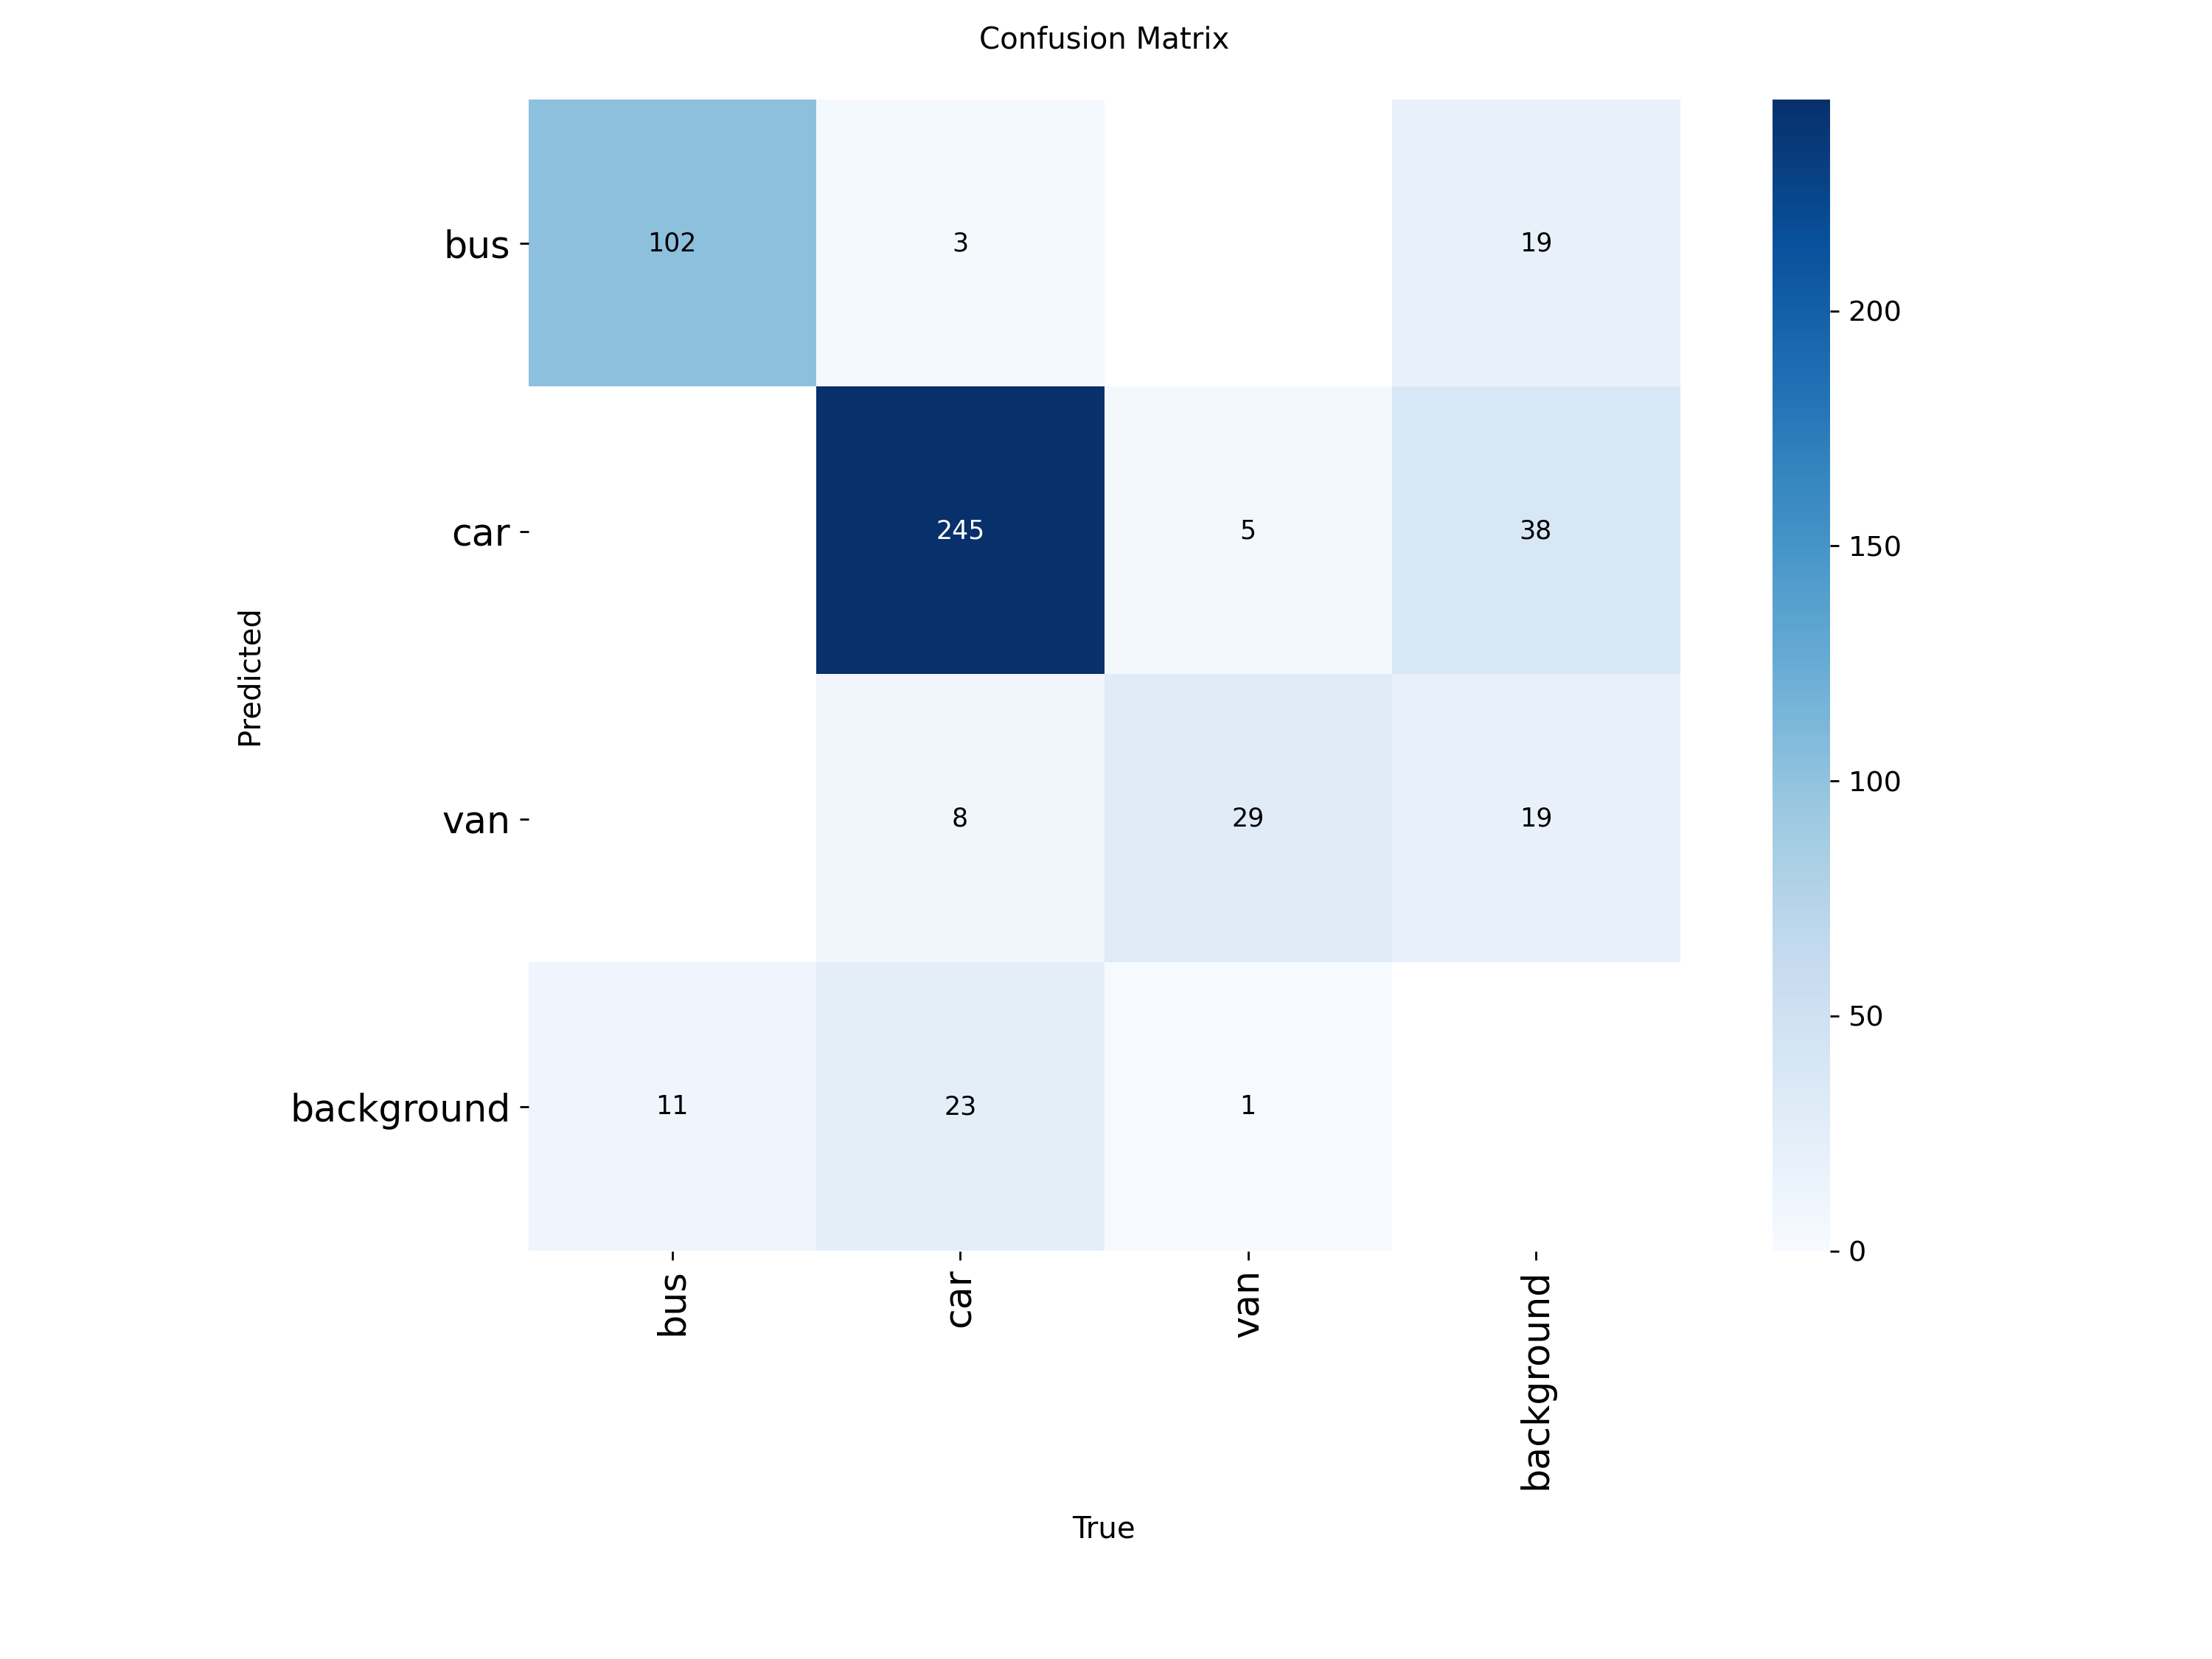

In [ ]:
from IPython.display import Image

Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=1000)

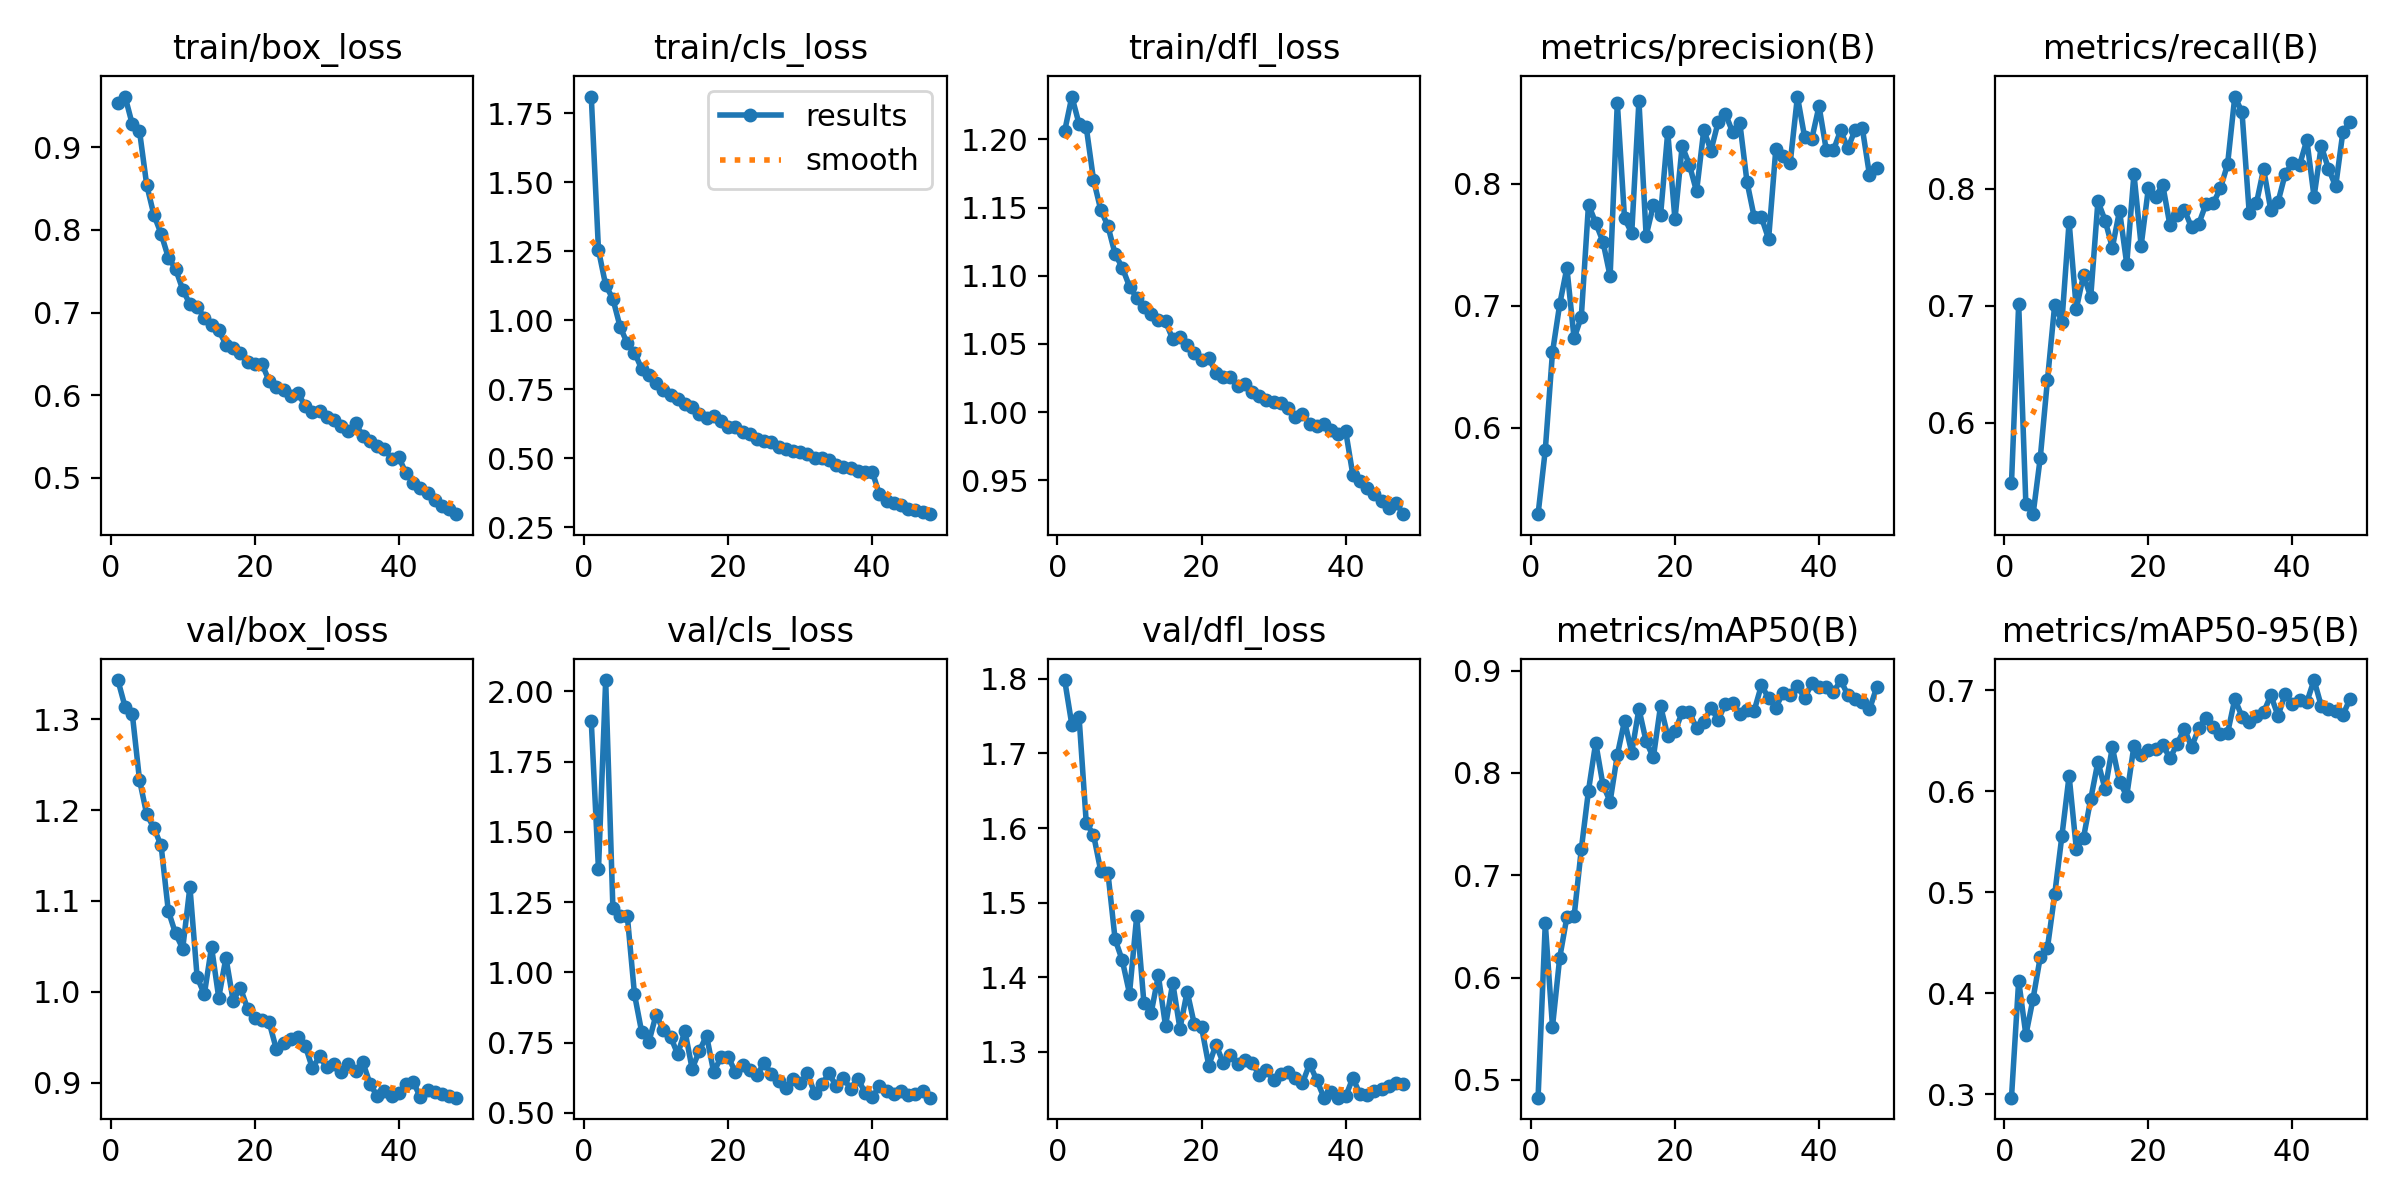

In [ ]:
from IPython.display import Image

Image(filename=f'{HOME}/runs/detect/train/results.png', width=1000)

In [ ]:
import supervision as sv

ds = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset_location}/test/images",
    annotations_directory_path=f"{dataset_location}/test/labels",
    data_yaml_path=f"{dataset_location}/data.yaml"
)

ds.classes

['bus', 'car', 'van']

In [ ]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

# Lists training artifacts such as weights, result plots, and confusion matrix.
!ls /content/drive/MyDrive/Pelatihan_YOLO/Model_Final/

args.yaml			 results.csv	       val_batch0_labels.jpg
BoxF1_curve.png			 results.png	       val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg      val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1.jpg      val_batch1_pred.jpg
BoxR_curve.png			 train_batch2.jpg      val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch40390.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch40391.jpg  weights
labels.jpg			 train_batch40392.jpg


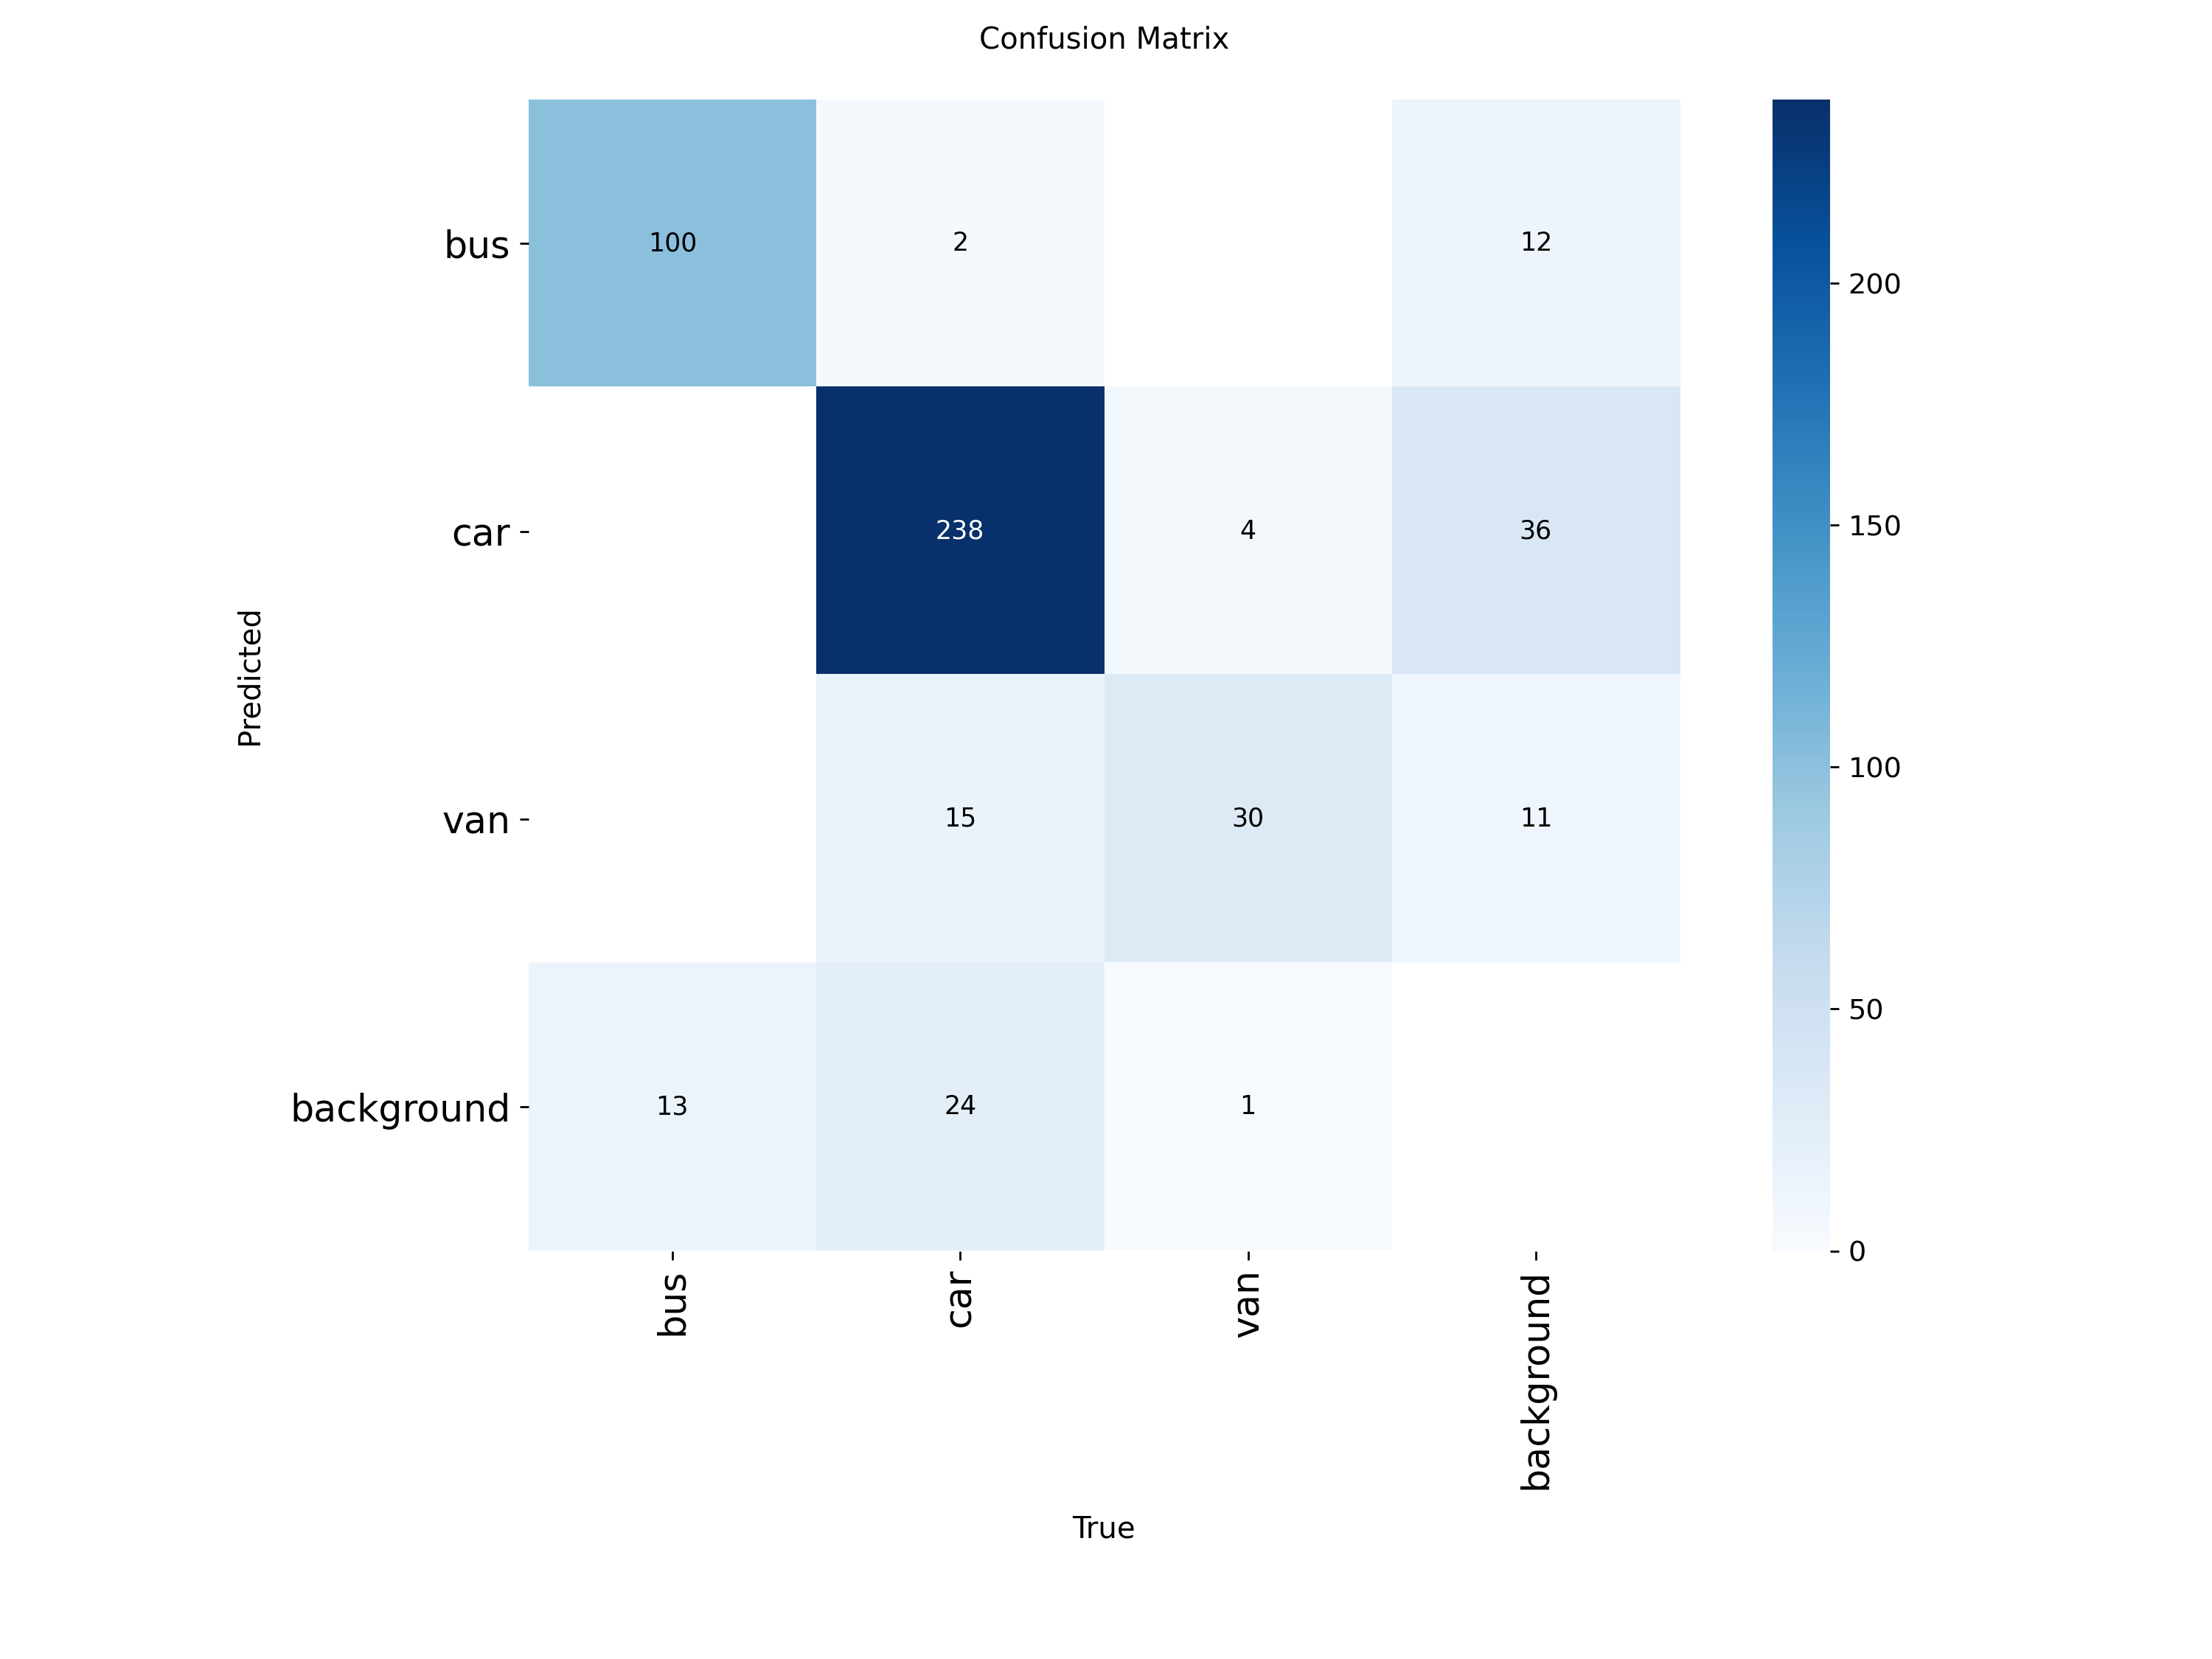

In [ ]:
from IPython.display import Image

# Menampilkan grafik Confusion Matrix
Image(filename='/content/drive/MyDrive/Pelatihan_YOLO/Model_Final/confusion_matrix.png', width=1000)

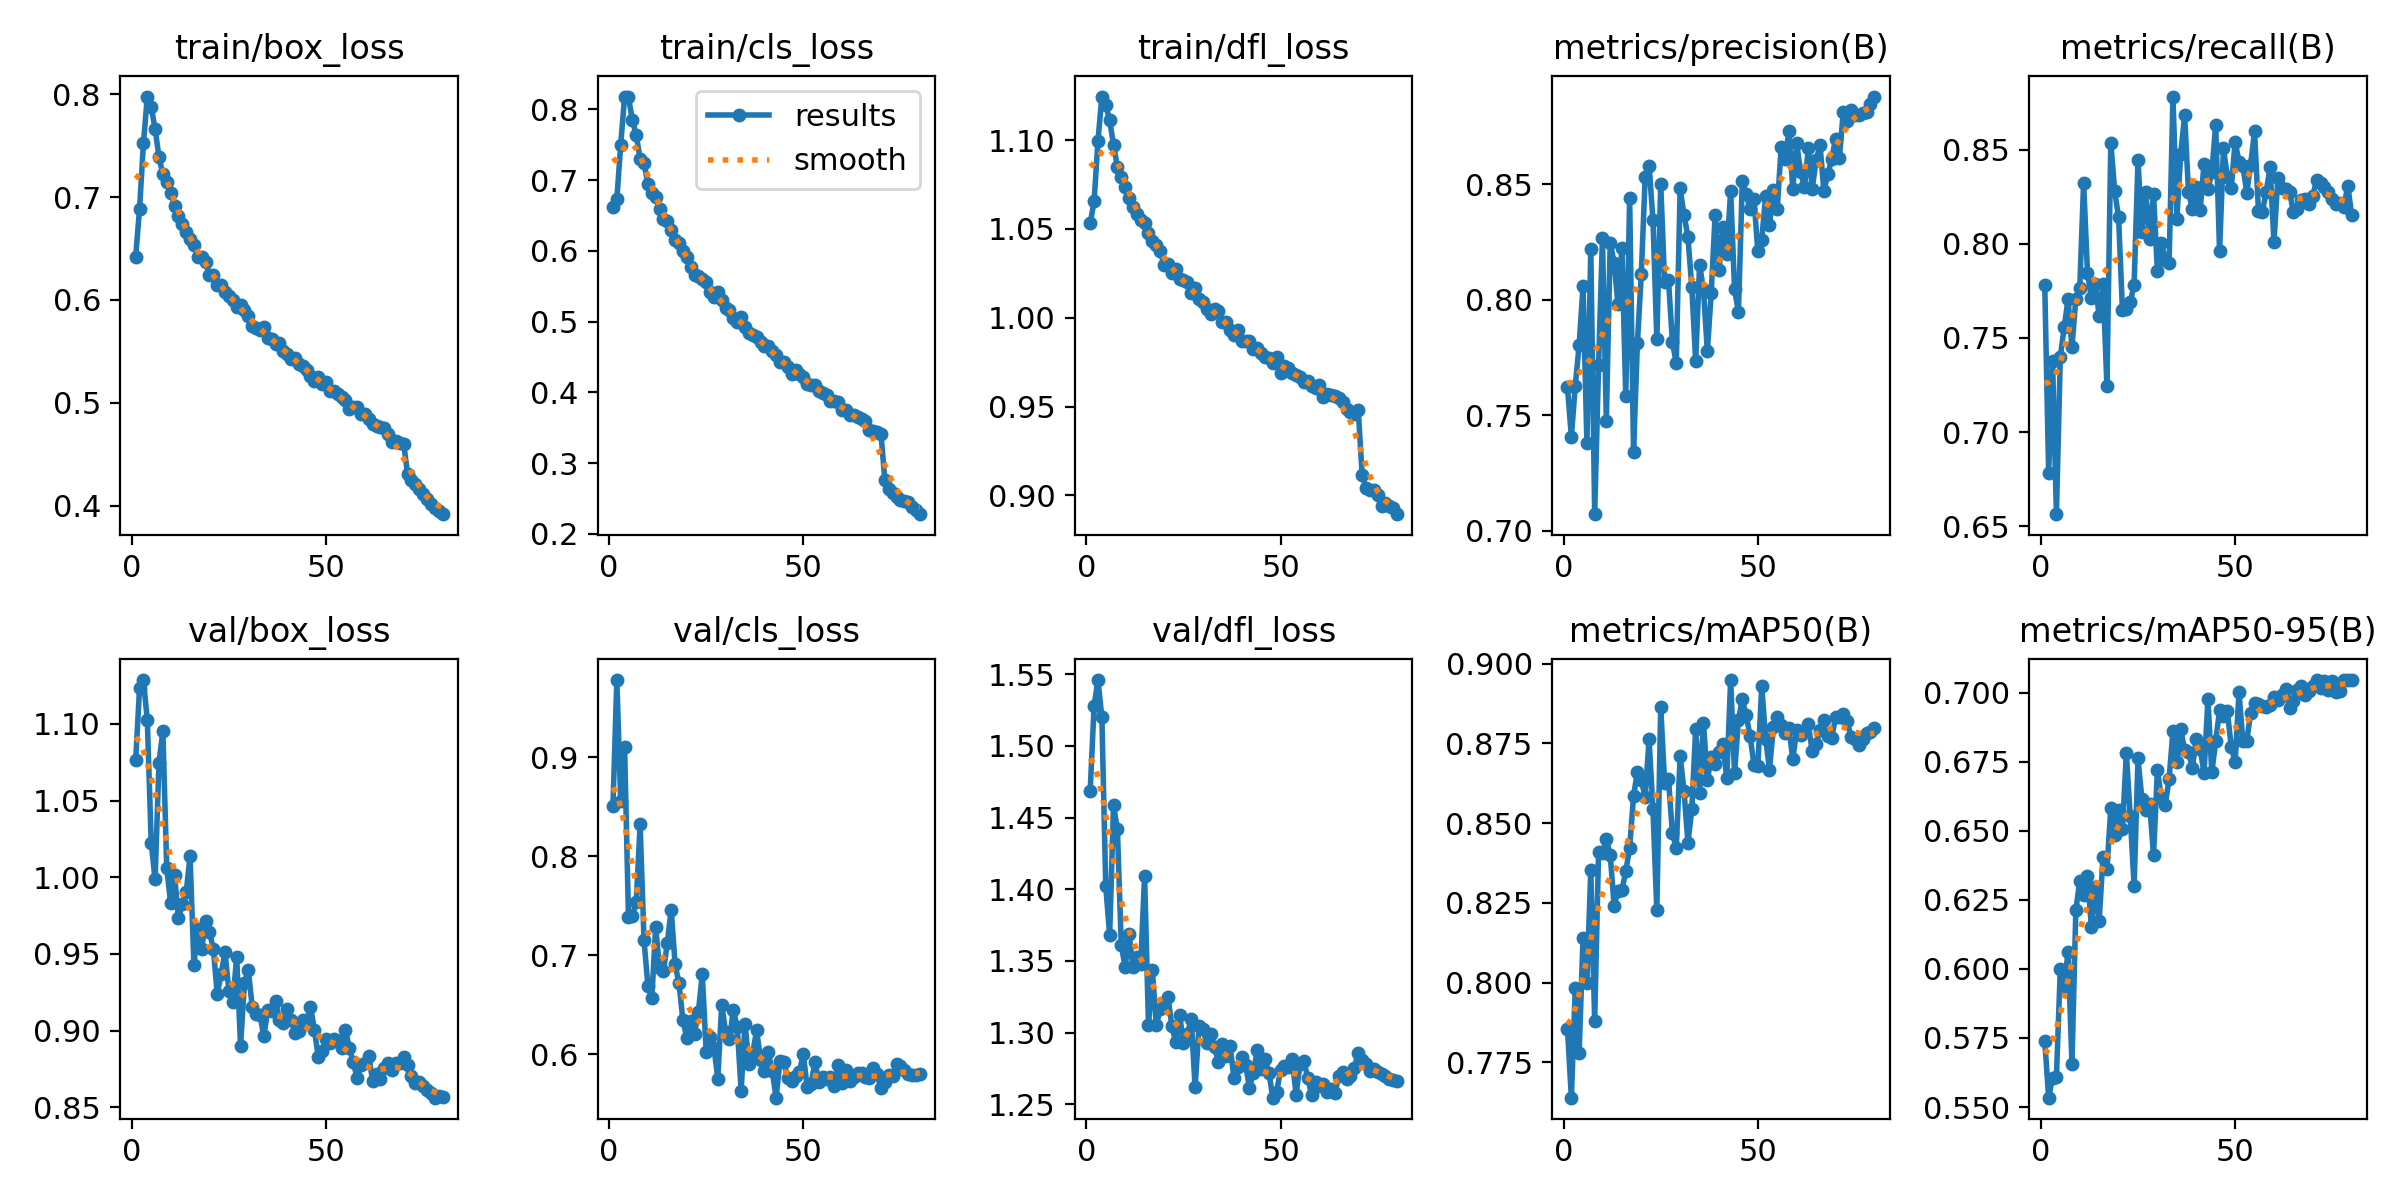

In [ ]:
from IPython.display import Image

Image(filename=f'/content/drive/MyDrive/Pelatihan_YOLO/Model_Final/results.png', width=1000)

In [ ]:
import supervision as sv

# Mendefinisikan lokasi folder dataset
dataset_location = '/content/vehicle-detection'

# Memuat dataset uji (test) menggunakan Supervision
ds = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset_location}/test/images",
    annotations_directory_path=f"{dataset_location}/test/labels",
    data_yaml_path=f"{dataset_location}/data.yaml"
)

# Menampilkan daftar kelas kendaraan
ds.classes

['bus', 'car', 'van']

In [ ]:
from supervision.metrics import MeanAveragePrecision

model = YOLO(f'/content/drive/MyDrive/Pelatihan_YOLO/Model_Final/weights/best.pt')

predictions = []
targets = []

for _, image, target in ds:
    results = model(image, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)

    predictions.append(detections)
    targets.append(target)

map = MeanAveragePrecision().update(predictions, targets).compute()

In [ ]:
!scp /content/drive/MyDrive/Pelatihan_YOLO/Model_Final/weights/best.pt  # REPLACE "Your_Folder" with your desired folder in Google Drive